In [ ]:
from google.colab import files
uploaded = files.upload()
print(uploaded.keys())

Saving kaggle.json to kaggle.json
dict_keys(['kaggle.json'])


In [ ]:
import os

!mkdir -p /root/.kaggle
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle configured.")
print("File exists:", os.path.exists("/root/.kaggle/kaggle.json"))



Kaggle configured.
File exists: True


In [ ]:
!kaggle datasets list -s temperature


ref                                                                title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sevgisarac/temperature-change                                      Temperature change                                    4262625  2024-11-02 05:09:37.150000          32979        316                1  
wkirgsn/electric-motor-temperature                                 Electric Motor Temperature                          122212134  2021-04-26 09:07:04.530000          29691        575                1  
zusmani/pakistan-temperature                                       Pakistan Temperature                                     8469  2021-03-19 00:22:44.243000           2766         79          

In [ ]:
!kaggle datasets list -s temperature


ref                                                                title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
sevgisarac/temperature-change                                      Temperature change                                    4262625  2024-11-02 05:09:37.150000          32979        316                1  
wkirgsn/electric-motor-temperature                                 Electric Motor Temperature                          122212134  2021-04-26 09:07:04.530000          29691        575                1  
zusmani/pakistan-temperature                                       Pakistan Temperature                                     8469  2021-03-19 00:22:44.243000           2766         79          

In [ ]:
!mkdir -p data
!kaggle datasets download -d atulanandjha/temperature-readings-iot-devices --unzip -p data

Dataset URL: https://www.kaggle.com/datasets/atulanandjha/temperature-readings-iot-devices
License(s): GNU Lesser General Public License 3.0
100% 1.02M/1.02M [00:00<00:00, 90.5MB/s]



In [ ]:
!ls data

IOT-temp.csv


In [ ]:
import pandas as pd

df = pd.read_csv("data/IOT-temp.csv")

print("Shape:", df.shape)
df.head()

Shape: (97606, 5)


,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


In [ ]:
df.isnull().sum()

,0
id,0
room_id/id,0
noted_date,0
temp,0
out/in,0


In [ ]:
df['noted_date'] = pd.to_datetime(df['noted_date'], format='%d-%m-%Y %H:%M')

In [ ]:
df = df.sort_values('noted_date')

In [ ]:
df = df.set_index('noted_date')

In [ ]:
df = df.drop(columns=['id'])

In [ ]:
df['out_in'] = df['out/in'].map({'In': 0, 'Out': 1})
df = df.drop(columns=['out/in'])

In [ ]:
df = df.drop(columns=['room_id/id'])

In [ ]:
df = df.groupby(df.index).mean()

In [ ]:
df = df.fillna(method='ffill')



/tmp/ipykernel_26500/1327823641.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
df_model = df.reset_index()

df_model = df_model.rename(columns={
    'noted_date': 'ds',
    'temp': 'y'
})

df_model['unique_id'] = 'temp_series'

df_model.head()

,ds,y,out_in,unique_id
0,2018-07-28 07:06:00,31.000000,0.000000,temp_series
1,2018-07-28 07:07:00,31.296296,0.296296,temp_series
2,2018-07-28 07:08:00,31.000000,0.200000,temp_series
3,2018-07-28 07:09:00,32.500000,1.000000,temp_series
4,2018-07-28 07:10:00,31.000000,0.000000,temp_series


In [ ]:
!pip install statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

# prepare data for Nixtla format (already done)
df_sf = df_model[['unique_id', 'ds', 'y']]

# create model
sf = StatsForecast(
    models=[AutoARIMA()],
    freq='T'  # minute frequency
)

# forecast next 60 steps
forecast = sf.forecast(df=df_sf, h=60)

forecast.head()

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:378: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:434: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


,unique_id,ds,AutoARIMA
0,temp_series,2018-12-08 09:31:00,32.988667
1,temp_series,2018-12-08 09:32:00,32.412339
2,temp_series,2018-12-08 09:33:00,32.844301
3,temp_series,2018-12-08 09:34:00,32.803172
4,temp_series,2018-12-08 09:35:00,32.851252


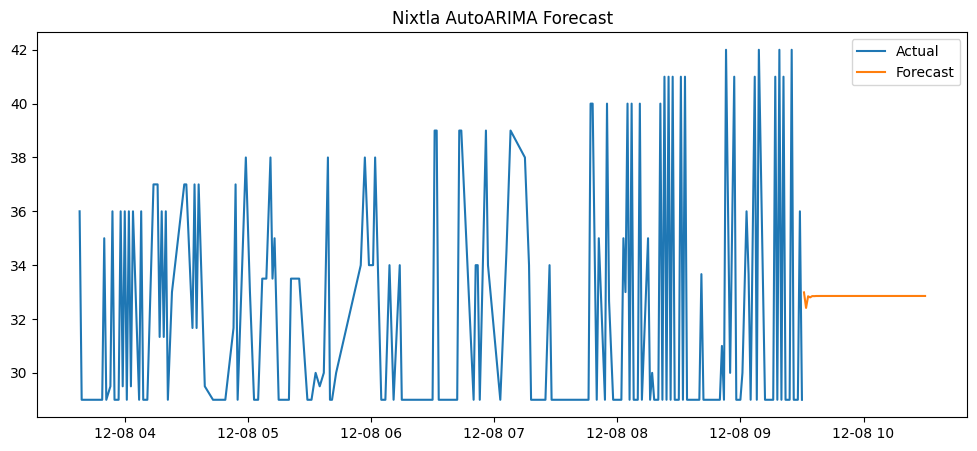

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df_sf['ds'][-200:], df_sf['y'][-200:], label='Actual')
plt.plot(forecast['ds'], forecast['AutoARIMA'], label='Forecast')

plt.legend()
plt.title("Nixtla AutoARIMA Forecast")
plt.show()

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# forecast horizon
h = 60

# split
train_sf = df_sf.iloc[:-h].copy()
test_sf = df_sf.iloc[-h:].copy()

# model
sf = StatsForecast(
    models=[AutoARIMA()],
    freq='min'
)

# forecast
fcst_test = sf.forecast(df=train_sf, h=h)

# reset indexes to align row-by-row
test_sf = test_sf.reset_index(drop=True)
fcst_test = fcst_test.reset_index(drop=True)

# build evaluation dataframe
eval_df = pd.DataFrame({
    'ds': test_sf['ds'],
    'actual': test_sf['y'],
    'predicted': fcst_test['AutoARIMA']
})

# metrics
mae = mean_absolute_error(eval_df['actual'], eval_df['predicted'])
mse = mean_squared_error(eval_df['actual'], eval_df['predicted'])
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

eval_df.head()

MAE: 4.665947367403193
MSE: 27.52719670394429
RMSE: 5.246636704017565


,ds,actual,predicted
0,2018-12-08 08:07:00,40.0,33.169388
1,2018-12-08 08:08:00,29.0,32.162401
2,2018-12-08 08:10:00,29.0,32.580315
3,2018-12-08 08:11:00,40.0,32.490420
4,2018-12-08 08:12:00,29.0,32.533007


In [ ]:
naive_mae = np.mean(np.abs(train_sf['y'].values[1:] - train_sf['y'].values[:-1]))
mase = mae / naive_mae if naive_mae != 0 else np.nan

print("Naive MAE:", naive_mae)
print("MASE:", mase)

Naive MAE: 2.4822738444489723
MASE: 1.8797069379905438


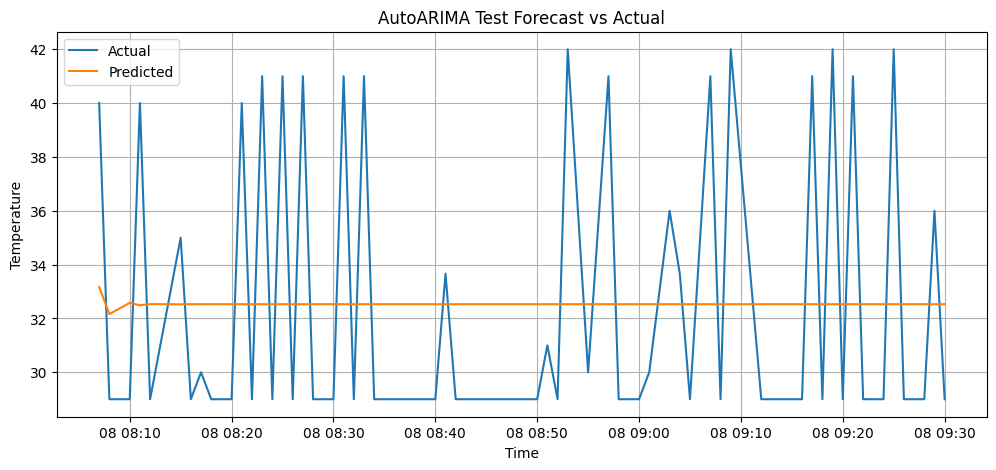

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(eval_df['ds'], eval_df['actual'], label='Actual')
plt.plot(eval_df['ds'], eval_df['predicted'], label='Predicted')
plt.title('AutoARIMA Test Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df_ml = df_sf.copy()

# time features
df_ml['hour'] = df_ml['ds'].dt.hour
df_ml['dayofweek'] = df_ml['ds'].dt.dayofweek

# lag features (VERY IMPORTANT)
df_ml['lag_1'] = df_ml['y'].shift(1)
df_ml['lag_2'] = df_ml['y'].shift(2)
df_ml['lag_3'] = df_ml['y'].shift(3)

# drop NaNs
df_ml = df_ml.dropna().reset_index(drop=True)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# features
features = ['hour', 'dayofweek', 'lag_1', 'lag_2', 'lag_3']
X = df_ml[features]
y = df_ml['y']

# split
h = 60
X_train, X_test = X[:-h], X[-h:]
y_train, y_test = y[:-h], y[-h:]

# model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

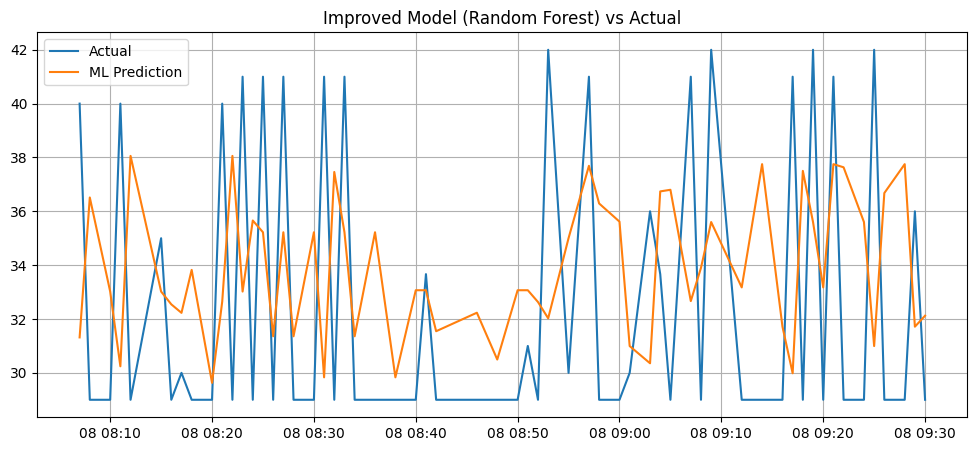

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_ml['ds'][-h:], y_test, label='Actual')
plt.plot(df_ml['ds'][-h:], y_pred, label='ML Prediction')
plt.title('Improved Model (Random Forest) vs Actual')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 5.511821876657295
RMSE: 6.208361410209728


In [ ]:
# MORE LAGS (memory)
df_ml['lag_5'] = df_ml['y'].shift(5)
df_ml['lag_10'] = df_ml['y'].shift(10)

# ROLLING FEATURES (trend awareness)
df_ml['rolling_mean_5'] = df_ml['y'].rolling(5).mean()
df_ml['rolling_std_5'] = df_ml['y'].rolling(5).std()

df_ml = df_ml.dropna().reset_index(drop=True)

In [ ]:
features.append('out_in')

In [ ]:
features = [
    'hour',
    'dayofweek',
    'lag_1', 'lag_2', 'lag_3',
    'lag_5', 'lag_10',
    'rolling_mean_5',
    'rolling_std_5'
]

In [ ]:
df_ml['state'] = (df_ml['y'] > 35).astype(int)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

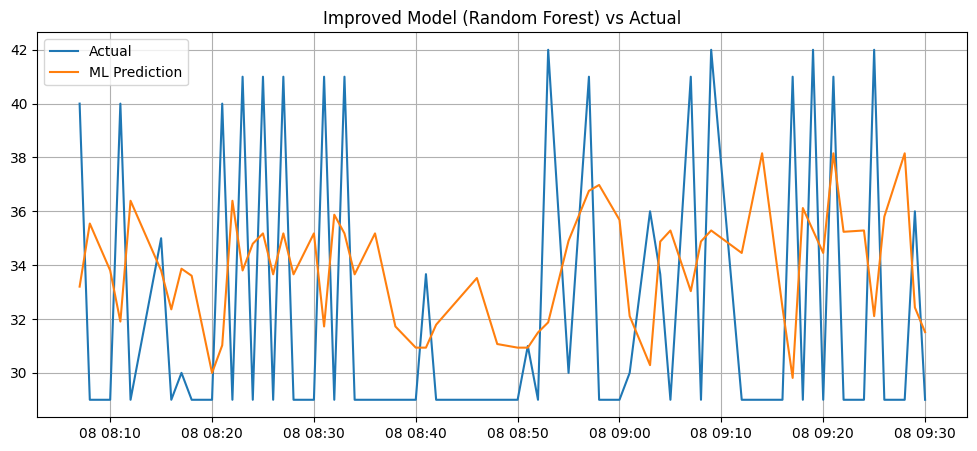

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df_ml['ds'][-h:], y_test, label='Actual')
plt.plot(df_ml['ds'][-h:], y_pred, label='ML Prediction')
plt.title('Improved Model (Random Forest) vs Actual')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# make sure your feature dataframe exists
# expected columns at least: temp, out_in, hour, dayofweek, lag_1, lag_2, lag_3

df_fe = df.copy()

# if hour/dayofweek are not in df yet, add them
if 'hour' not in df_fe.columns:
    df_fe['hour'] = df_fe.index.hour
if 'dayofweek' not in df_fe.columns:
    df_fe['dayofweek'] = df_fe.index.dayofweek

# if lag columns are not in df yet, add them
if 'lag_1' not in df_fe.columns:
    df_fe['lag_1'] = df_fe['temp'].shift(1)
if 'lag_2' not in df_fe.columns:
    df_fe['lag_2'] = df_fe['temp'].shift(2)
if 'lag_3' not in df_fe.columns:
    df_fe['lag_3'] = df_fe['temp'].shift(3)

df_fe = df_fe.dropna().copy()

split_ratio = 0.8
split_index_fe = int(len(df_fe) * split_ratio)

train_df_fe = df_fe.iloc[:split_index_fe].copy()
test_df_fe = df_fe.iloc[split_index_fe:].copy()

scaler_fe = MinMaxScaler()
scaled_column_name_fe = 'temp_scaled'

train_df_fe[scaled_column_name_fe] = scaler_fe.fit_transform(train_df_fe[['temp']])
test_df_fe[scaled_column_name_fe] = scaler_fe.transform(test_df_fe[['temp']])

print("Training shape:", train_df_fe.shape)
print("Testing shape:", test_df_fe.shape)
print(train_df_fe[['temp', scaled_column_name_fe, 'hour', 'lag_1']].head())

Training shape: (22333, 8)
Testing shape: (5584, 8)
                       temp  temp_scaled  hour  lag_1
noted_date                                           
2018-07-28 07:09:00  32.500     0.362069     7   31.0
2018-07-28 07:10:00  31.000     0.310345     7   32.5
2018-07-28 07:14:00  32.000     0.344828     7   31.0
2018-07-28 07:15:00  32.000     0.344828     7   32.0
2018-07-28 07:16:00  31.625     0.331897     7   32.0


In [ ]:
import numpy as np

def create_sequences(data, seq_length):
    xs = []
    for i in range(len(data) - seq_length + 1):
        x = data[i:(i + seq_length)]
        xs.append(x)
    return np.array(xs)

sequence_length = 24
if sequence_length > len(train_df_fe):
    sequence_length = max(8, len(train_df_fe) // 4)

scaled_train_data_fe = train_df_fe[scaled_column_name_fe].values

vae_train_sequences = create_sequences(scaled_train_data_fe, sequence_length)
vae_train_sequences = vae_train_sequences.reshape((-1, sequence_length, 1))

print("Created sequences:", len(vae_train_sequences))
print("VAE training shape:", vae_train_sequences.shape)

Created sequences: 22310
VAE training shape: (22310, 24, 1)


In [ ]:
!pip install -q tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

tf.random.set_seed(42)
np.random.seed(42)

latent_dim = 8
input_shape = (sequence_length, 1)

# ----- Encoder -----
encoder_inputs = layers.Input(shape=input_shape)
x = layers.LSTM(32, return_sequences=False)(encoder_inputs)
x = layers.Dense(16, activation='relu')(x)
z_mean = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, name='z')([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')

# ----- Decoder -----
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(16, activation='relu')(latent_inputs)
x = layers.Dense(32, activation='relu')(x)
x = layers.RepeatVector(sequence_length)(x)
x = layers.LSTM(32, return_sequences=True)(x)
decoder_outputs = layers.TimeDistributed(layers.Dense(1))(x)

decoder = Model(latent_inputs, decoder_outputs, name='decoder')

# ----- VAE -----
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(data - reconstruction), axis=[1, 2])
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = reconstruction_loss + 0.01 * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3))

history = vae.fit(
    vae_train_sequences,
    epochs=15,
    batch_size=64,
    shuffle=True,
    verbose=1
)

Epoch 1/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - kl_loss: 7.8825 - loss: 0.9257 - reconstruction_loss: 0.8469
Epoch 2/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - kl_loss: 7.0180 - loss: 0.4865 - reconstruction_loss: 0.4163
Epoch 3/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - kl_loss: 5.2761 - loss: 0.4582 - reconstruction_loss: 0.4054
Epoch 4/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - kl_loss: 4.3070 - loss: 0.4432 - reconstruction_loss: 0.4001
Epoch 5/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - kl_loss: 3.6574 - loss: 0.4338 - reconstruction_loss: 0.3972
Epoch 6/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - kl_loss: 3.2519 - loss: 0.4280 - reconstruction_loss: 0.3955
Epoch 7/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - kl_loss: 3.0387 - loss: 0.4249 - reconstruction_loss: 0.3945
Epoch 8/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - kl_loss: 2.8888 - loss: 0.4225 - reconstruction_loss: 0.3936
Epoch 9/15
349/349 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - kl_loss: 2.761

In [ ]:
n_synth = 300
z_random = np.random.normal(size=(n_synth, latent_dim))
synthetic_sequences = decoder.predict(z_random, verbose=0)

print("Synthetic sequences shape:", synthetic_sequences.shape)

Synthetic sequences shape: (300, 24, 1)


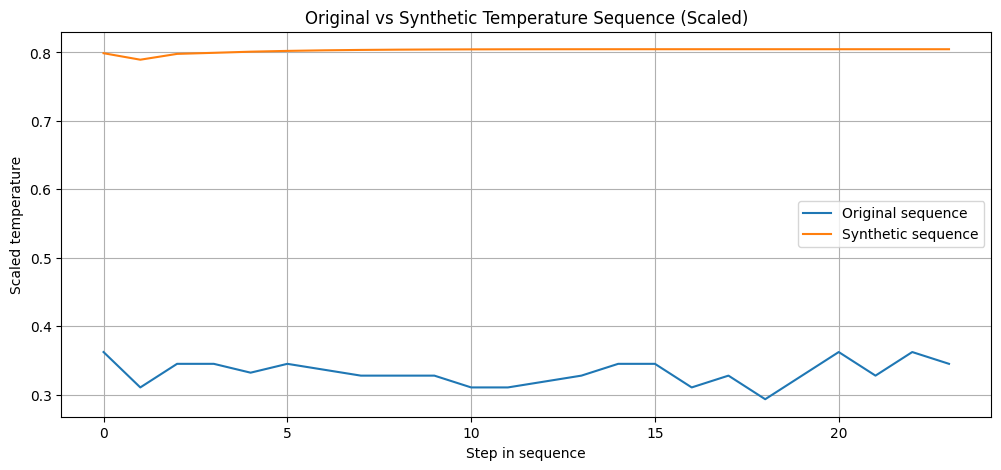

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(vae_train_sequences[0].flatten(), label='Original sequence')
plt.plot(synthetic_sequences[0].flatten(), label='Synthetic sequence')
plt.title('Original vs Synthetic Temperature Sequence (Scaled)')
plt.xlabel('Step in sequence')
plt.ylabel('Scaled temperature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
synthetic_flat = synthetic_sequences.reshape(-1)

print("Synthetic flat shape:", synthetic_flat.shape)

Synthetic flat shape: (7200,)


In [ ]:
augmented_y = np.concatenate([
    train_df_fe['temp_scaled'].values,
    synthetic_flat
])

print("Augmented size:", len(augmented_y))

Augmented size: 29533


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# original training
X_train_simple = np.arange(len(train_df_fe)).reshape(-1, 1)
y_train_simple = train_df_fe['temp_scaled'].values

# augmented training
X_aug = np.arange(len(augmented_y)).reshape(-1, 1)

model_aug = RandomForestRegressor(n_estimators=100, random_state=42)
model_aug.fit(X_aug, augmented_y)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_aug = model_aug.predict(X_train_simple[-60:])

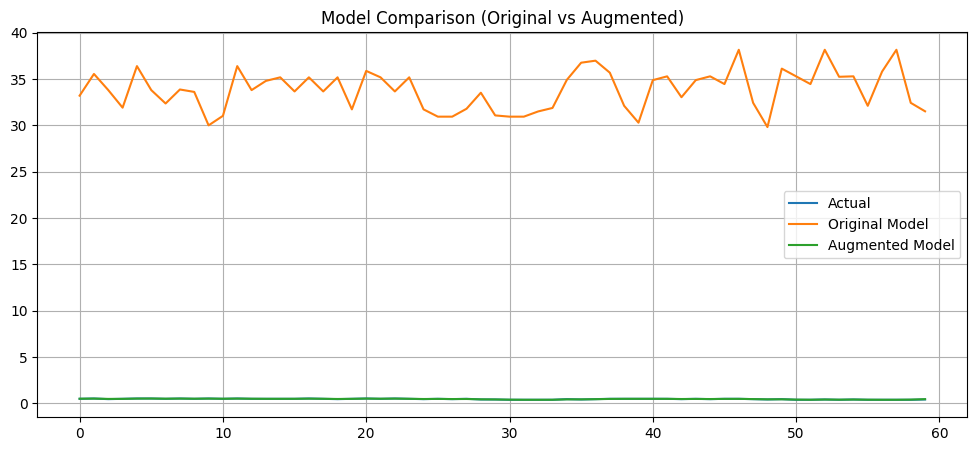

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# actual
plt.plot(y_train_simple[-60:], label='Actual')

# original model
plt.plot(y_pred, label='Original Model')

# augmented model
plt.plot(y_pred_aug, label='Augmented Model')

plt.title('Model Comparison (Original vs Augmented)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

df_final = df.copy()

# time features
df_final['hour'] = df_final.index.hour
df_final['dayofweek'] = df_final.index.dayofweek

# lag features
df_final['lag_1'] = df_final['temp'].shift(1)
df_final['lag_2'] = df_final['temp'].shift(2)
df_final['lag_3'] = df_final['temp'].shift(3)

df_final = df_final.dropna().copy()

print(df_final.head())
print(df_final.shape)

                       temp  out_in  hour  dayofweek  lag_1      lag_2  \
noted_date                                                               
2018-07-28 07:09:00  32.500     1.0     7          5   31.0  31.296296   
2018-07-28 07:10:00  31.000     0.0     7          5   32.5  31.000000   
2018-07-28 07:14:00  32.000     1.0     7          5   31.0  32.500000   
2018-07-28 07:15:00  32.000     1.0     7          5   32.0  31.000000   
2018-07-28 07:16:00  31.625     1.0     7          5   32.0  32.000000   

                         lag_3  
noted_date                      
2018-07-28 07:09:00  31.000000  
2018-07-28 07:10:00  31.296296  
2018-07-28 07:14:00  31.000000  
2018-07-28 07:15:00  32.500000  
2018-07-28 07:16:00  31.000000  
(27917, 7)


In [ ]:
features = ['hour', 'dayofweek', 'out_in', 'lag_1', 'lag_2', 'lag_3']
target = 'temp'

h = 60

train_real = df_final.iloc[:-h].copy()
test_real = df_final.iloc[-h:].copy()

X_train_real = train_real[features]
y_train_real = train_real[target]

X_test_real = test_real[features]
y_test_real = test_real[target]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_real = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model_real.fit(X_train_real, y_train_real)
y_pred_real = model_real.predict(X_test_real)

In [ ]:
# synthetic_sequences shape: (n_synth, sequence_length, 1)

synthetic_flat_scaled = synthetic_sequences.reshape(-1, 1)

synthetic_flat_temp = scaler_fe.inverse_transform(synthetic_flat_scaled).flatten()

print("Synthetic temp min:", synthetic_flat_temp.min())
print("Synthetic temp max:", synthetic_flat_temp.max())
print(synthetic_flat_temp[:10])

Synthetic temp min: 23.990807
Synthetic temp max: 50.515705
[45.16705  44.89173  45.13823  45.183388 45.231453 45.265026 45.2894
 45.3062   45.31748  45.32486 ]


In [ ]:
synthetic_df = pd.DataFrame({'temp': synthetic_flat_temp})

# create simple synthetic time-like features
# we recycle hour/dayofweek patterns from real training data
hour_pattern = train_real['hour'].values
day_pattern = train_real['dayofweek'].values
out_in_pattern = train_real['out_in'].values

synthetic_len = len(synthetic_df)

synthetic_df['hour'] = [hour_pattern[i % len(hour_pattern)] for i in range(synthetic_len)]
synthetic_df['dayofweek'] = [day_pattern[i % len(day_pattern)] for i in range(synthetic_len)]
synthetic_df['out_in'] = [out_in_pattern[i % len(out_in_pattern)] for i in range(synthetic_len)]

synthetic_df['lag_1'] = synthetic_df['temp'].shift(1)
synthetic_df['lag_2'] = synthetic_df['temp'].shift(2)
synthetic_df['lag_3'] = synthetic_df['temp'].shift(3)

synthetic_df = synthetic_df.dropna().copy()

print(synthetic_df.head())
print(synthetic_df.shape)

        temp  hour  dayofweek  out_in      lag_1      lag_2      lag_3
3  45.183388     7          5     1.0  45.138229  44.891731  45.167049
4  45.231453     7          5     1.0  45.183388  45.138229  44.891731
5  45.265026     7          5     1.0  45.231453  45.183388  45.138229
6  45.289398     7          5     1.0  45.265026  45.231453  45.183388
7  45.306198     7          5     1.0  45.289398  45.265026  45.231453
(7197, 7)


In [ ]:
aug_train = pd.concat(
    [
        train_real[['temp', 'hour', 'dayofweek', 'out_in', 'lag_1', 'lag_2', 'lag_3']],
        synthetic_df[['temp', 'hour', 'dayofweek', 'out_in', 'lag_1', 'lag_2', 'lag_3']]
    ],
    ignore_index=True
)

X_train_aug = aug_train[features]
y_train_aug = aug_train[target]

print("Real train size:", len(train_real))
print("Synthetic rows:", len(synthetic_df))
print("Augmented train size:", len(aug_train))

Real train size: 27857
Synthetic rows: 7197
Augmented train size: 35054


In [ ]:
model_aug = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model_aug.fit(X_train_aug, y_train_aug)
y_pred_aug = model_aug.predict(X_test_real)

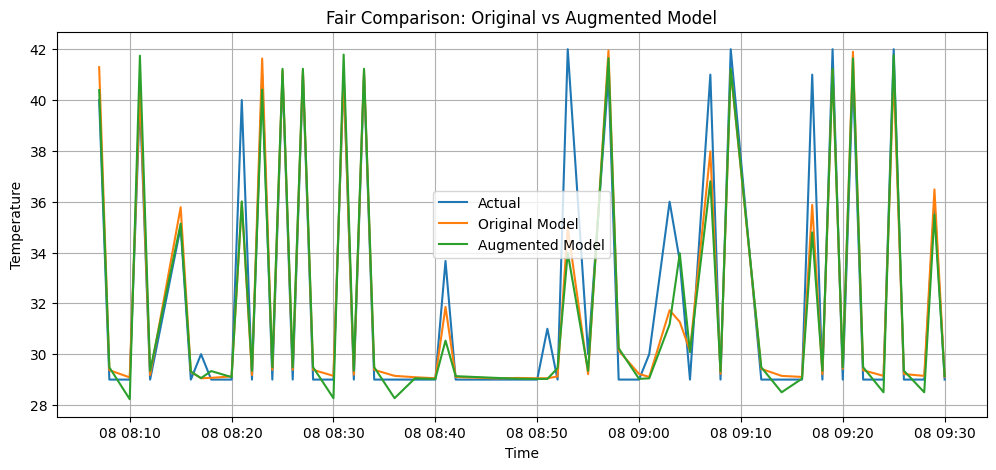

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(test_real.index, y_test_real, label='Actual')
plt.plot(test_real.index, y_pred_real, label='Original Model')
plt.plot(test_real.index, y_pred_aug, label='Augmented Model')
plt.title('Fair Comparison: Original vs Augmented Model')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

mae_aug = mean_absolute_error(y_test_real, y_pred_aug)
rmse_aug = np.sqrt(mean_squared_error(y_test_real, y_pred_aug))

print("Original Model MAE:", mae_real)
print("Original Model RMSE:", rmse_real)
print("Augmented Model MAE:", mae_aug)
print("Augmented Model RMSE:", rmse_aug)

Original Model MAE: 0.8299299089269581
Original Model RMSE: 1.5590012186702729
Augmented Model MAE: 0.9472211267442845
Augmented Model RMSE: 1.7817137387700235
